CS4001/4042 Assignment 1
---
Part B, Q1 (15 marks)
---

Real world datasets often have a mix of numeric and categorical features – this dataset is one example. To build models on such data, categorical features have to be encoded or embedded.

PyTorch Tabular is a library that makes it very convenient to build neural networks for tabular data. It is built on top of PyTorch Lightning, which abstracts away boilerplate model training code and makes it easy to integrate other tools, e.g. TensorBoard for experiment tracking.

For questions B1 and B2, the following features should be used:   
- **Numeric / Continuous** features: dist_to_nearest_stn, dist_to_dhoby, degree_centrality, eigenvector_centrality, remaining_lease_years, floor_area_sqm
- **Categorical** features: month, town, flat_model_type, storey_range



---



In [ ]:
!pip install pytorch_tabular[extra]

In [ ]:
SEED = 42

import os

import random
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd

import torch
import torch.nn as nn

from pytorch_tabular import TabularModel
from pytorch_tabular.models import CategoryEmbeddingModelConfig
from pytorch_tabular.config import (
    DataConfig,
    OptimizerConfig,
    TrainerConfig,
)

> Divide the dataset (‘hdb_price_prediction.csv’) into train and test sets by using entries from year 2020 and before as training data, and year 2021 as test data (validation set is not required).
**Do not** use data from year 2022 and year 2023.



In [ ]:
df = pd.read_csv('hdb_price_prediction.csv')

# TODO: Enter your code here

# Split the dataset
train_df = df[df["year"] <= 2020]  # Training data (2020 and before)
test_df = df[df["year"] == 2021]   # Test data (only 2021)

# Check the number of entries in each set
train_size = train_df.shape[0]
test_size = test_df.shape[0]

print(f"Training set size: {train_size}")
print(f"Test set size: {test_size}")

Training set size: 87370
Test set size: 29057


> Refer to the documentation of **PyTorch Tabular** and perform the following tasks: https://pytorch-tabular.readthedocs.io/en/latest/#usage
- Use **[DataConfig](https://pytorch-tabular.readthedocs.io/en/latest/data/)** to define the target variable, as well as the names of the continuous and categorical variables.
- Use **[TrainerConfig](https://pytorch-tabular.readthedocs.io/en/latest/training/)** to automatically tune the learning rate. Set batch_size to be 1024 and set max_epoch as 50.
- Use **[CategoryEmbeddingModelConfig](https://pytorch-tabular.readthedocs.io/en/latest/models/#category-embedding-model)** to create a feedforward neural network with 1 hidden layer containing 50 neurons.
- Use **[OptimizerConfig](https://pytorch-tabular.readthedocs.io/en/latest/optimizer/)** to choose Adam optimiser. There is no need to set the learning rate (since it will be tuned automatically) nor scheduler.
- Use **[TabularModel](https://pytorch-tabular.readthedocs.io/en/latest/tabular_model/)** to initialise the model and put all the configs together.

In [ ]:
# TODO: Enter your code here

# Define the target variable and features
data_config = DataConfig(
    target=["resale_price"],  # Target variable
    continuous_cols=[
        "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
        "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
    ],  # Continuous variables
    categorical_cols=["town", "full_address", "nearest_stn", "flat_model_type", "storey_range"],  # Categorical variables
)

# Trainer configuration with learning rate tuning
trainer_config = TrainerConfig(
    auto_lr_find=True,  # Automatically tune learning rate
    batch_size=1024,
    max_epochs=50,
)

# Neural network model configuration
model_config = CategoryEmbeddingModelConfig(
    task="regression",
    # layers=[50],  # One hidden layer with 50 neurons
    layers="50",  # Correct: String format
    activation="ReLU",
)

# Optimizer configuration
optimizer_config = OptimizerConfig(
    optimizer="Adam",  # Adam optimizer
)

# Initialize the TabularModel with all configurations
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

print(tabular_model)

INFO:pytorch_tabular.tabular_model:Experiment Tracking is turned off


TabularModel(model=CategoryEmbeddingModel(Not Initialized))


> Report the test RMSE error and the test R2 value that you obtained.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Fit the model
tabular_model.fit(train=train_df)

# Make predictions
predictions = tabular_model.predict(test_df)

# Debug: Print column names
print(predictions.columns)

# Extract actual and predicted values
y_true = test_df["resale_price"].values
y_pred = predictions.iloc[:, 0].values  # Adjust based on actual output

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Compute R² score
r2 = r2_score(y_true, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_tabular.tabular_model:Preparing the DataLoaders
INFO:pytorch_tabular.tabular_datamodule:Setting up the datamodule for regression task
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_encoded[col].fillna(self._imputed, inplace=True)
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame 

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.tuner.lr_finder:Learning rate set to 0.47863009232263803
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_e62b158b-91f7-4160-8343-5cb817b2b673.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_e62b158b-91f7-4160-8343-5cb817b2b673.ckpt
INFO:pytorch_tabular.tabular_model:Suggested LR: 0.47863009232263803. For plot and detailed analysis, use `find_learning_rate` method.
INFO:pytorch_tabular.tabular_model:Training Started
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ CategoryEmbeddingBackbone │  7.3 K │ train │
│ 1 │ _embedding_layer │ Embedding1dLayer          │  448 K │ train │
│ 2 │ head             │ LinearHead                │     51 │ train │
│ 3 │ loss             │ MSELoss                   │      0 │ train │
└───┴──────────────────┴───────────────────────────┴────────┴───────┘

Trainable params: 455 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 455 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0

Output()

INFO:pytorch_tabular.tabular_model:Training the model completed
INFO:pytorch_tabular.tabular_model:Loading the best model
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/utils/python_utils.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please op

Index(['resale_price_prediction'], dtype='object')
Test RMSE: 73491.3736
Test R²: 0.7958


> Print out the corresponding rows in the dataframe for the top 25 test samples with the largest errors.



In [ ]:
# TODO: Enter your code here
import pandas as pd

# Compute absolute errors
test_df["absolute_error"] = np.abs(y_true - y_pred)

# Sort by absolute error (largest first)
top_25_errors = test_df.sort_values(by="absolute_error", ascending=False).head(25)

# Print the top 25 rows with the largest errors
print(top_25_errors)


        month  year             town               full_address  \
92226       9  2021      BUKIT MERAH         96A HENDERSON ROAD   
90608      12  2021           BISHAN      273B BISHAN STREET 24   
92442      11  2021      BUKIT MERAH         127D KIM TIAN ROAD   
92443      11  2021      BUKIT MERAH         96A HENDERSON ROAD   
96910      12  2021          GEYLANG           332 UBI AVENUE 1   
100836      6  2021  KALLANG/WHAMPOA           39 JALAN BAHAGIA   
106132     11  2021       QUEENSTOWN      50 COMMONWEALTH DRIVE   
90432       8  2021           BISHAN      275A BISHAN STREET 24   
105702      6  2021       QUEENSTOWN        150 MEI LING STREET   
90523      10  2021           BISHAN      273B BISHAN STREET 24   
90431       8  2021           BISHAN      273A BISHAN STREET 24   
92340      10  2021      BUKIT MERAH           56 HAVELOCK ROAD   
90483       9  2021           BISHAN      273A BISHAN STREET 24   
114389     10  2021        WOODLANDS    805 WOODLANDS STREET 8

<ipython-input-7-292c2f06e0fe>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["absolute_error"] = np.abs(y_true - y_pred)


Part B, Q2 (10 marks)
---
In Question B1, we used the Category Embedding model. This creates a feedforward neural network in which the categorical features get learnable embeddings. In this question, we will make use of a library called Pytorch-WideDeep. This library makes it easy to work with multimodal deep-learning problems combining images, text, and tables. We will just be utilizing the deeptabular component of this library through the TabMlp network.

In [ ]:
!pip install pytorch-widedeep

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.0/22.0 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [ ]:
from pytorch_widedeep.preprocessing import TabPreprocessor
from pytorch_widedeep.models import TabMlp, WideDeep
from pytorch_widedeep import Trainer
from pytorch_widedeep.metrics import R2Score

>Divide the dataset (‘hdb_price_prediction.csv’) into train and test sets by using entries from the year 2020 and before as training data, and entries from 2021 and after as the test data（validation set is not required here).

In [ ]:
# Install the required library
!pip install pytorch-widedeep

import pandas as pd
import numpy as np
import torch
from pytorch_widedeep.preprocessing import TabPreprocessor
from pytorch_widedeep.models import TabMlp, WideDeep
from pytorch_widedeep import Trainer
from pytorch_widedeep.metrics import R2Score
from sklearn.metrics import mean_squared_error

# 1️⃣ Load the dataset
df = pd.read_csv('hdb_price_prediction.csv')

# 2️⃣ Ensure 'year' column is integer
df['year'] = pd.to_numeric(df['year'], errors='coerce')  # Convert year column if needed

# 3️⃣ Split dataset
train_df = df[df['year'] <= 2020]  # Training: 2020 and before
test_df = df[df['year'] >= 2021]   # Testing: 2021 and after

print(test_df)

        month  year        town              full_address   nearest_stn  \
87370       1  2021  ANG MO KIO   170 ANG MO KIO AVENUE 4  Yio Chu Kang   
87371       1  2021  ANG MO KIO   170 ANG MO KIO AVENUE 4  Yio Chu Kang   
87372       1  2021  ANG MO KIO   331 ANG MO KIO AVENUE 1    Ang Mo Kio   
87373       1  2021  ANG MO KIO  534 ANG MO KIO AVENUE 10    Ang Mo Kio   
87374       1  2021  ANG MO KIO  561 ANG MO KIO AVENUE 10    Ang Mo Kio   
...       ...   ...         ...                       ...           ...   
159548      8  2023      YISHUN      344 YISHUN AVENUE 11        Yishun   
159549      8  2023      YISHUN        325 YISHUN CENTRAL        Yishun   
159550      8  2023      YISHUN        325 YISHUN CENTRAL        Yishun   
159551      8  2023      YISHUN      387 YISHUN RING ROAD        Yishun   
159552      8  2023      YISHUN      277 YISHUN STREET 22        Yishun   

        dist_to_nearest_stn  dist_to_dhoby  degree_centrality  \
87370              1.276775       

>Refer to the documentation of Pytorch-WideDeep and perform the following tasks:
https://pytorch-widedeep.readthedocs.io/en/latest/index.html
* Use [**TabPreprocessor**](https://pytorch-widedeep.readthedocs.io/en/latest/examples/01_preprocessors_and_utils.html#2-tabpreprocessor) to create the deeptabular component using the continuous
features and the categorical features. Use this component to transform the training dataset.
* Create the [**TabMlp**](https://pytorch-widedeep.readthedocs.io/en/latest/pytorch-widedeep/model_components.html#pytorch_widedeep.models.tabular.mlp.tab_mlp.TabMlp) model with 2 hidden layers in the MLP, with 200 and 100 neurons respectively.
* Create a [**Trainer**](https://pytorch-widedeep.readthedocs.io/en/latest/pytorch-widedeep/trainer.html#pytorch_widedeep.training.Trainer) for the training of the created TabMlp model with the root mean squared error (RMSE) cost function. Train the model for 60 epochs using this trainer, keeping a batch size of 64. (Note: set the *num_workers* parameter to 0.)

In [ ]:

from pytorch_widedeep.preprocessing import TabPreprocessor
from pytorch_widedeep.models import TabMlp, WideDeep
from pytorch_widedeep.metrics import R2Score
from pytorch_widedeep.training import Trainer  # ✅ Correct


# Define categorical and continuous columns
cat_embed_cols = ["town", "full_address", "nearest_stn", "flat_model_type", "storey_range"]
continuous_cols = ["dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality", "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"]

# Use TabPreprocessor to create the deeptabular component
tab_preprocessor = TabPreprocessor(
    cat_embed_cols=cat_embed_cols,
    continuous_cols=continuous_cols
)

# For Training
X_tab = tab_preprocessor.fit_transform(train_df)  # x_train
target = train_df["resale_price"].values  # y_train

# Create the TabMlp model with 2 linear layers in the MLP, with 200 and 100 neurons respectively.
model = TabMlp(
    column_idx=tab_preprocessor.column_idx,
    cat_embed_input=tab_preprocessor.cat_embed_input,
    continuous_cols=continuous_cols,
    mlp_hidden_dims=[200, 100]
)

# Create a Trainer for the training of the created TabMlp model with the RMSE cost function
wide_deep_model = WideDeep(deeptabular=model)  # Combine the TabMlp model with any other models you want to use

Trainer_ = Trainer(
    wide_deep_model,
    objective="root_mean_squared_error",
    metrics=[R2Score],
    num_workers=0
)

# Train the model for 100 epochs using this trainer, keeping a batch size of 64.
Trainer_.fit(X_tab=X_tab, target=target, n_epochs=60, batch_size=64)


'''
# TODO: Enter your code here
# 4️⃣ Define features
target_col = "resale_price"

continuous_cols = [
    "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
    "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
]

cat_embed_input = ["town", "full_address", "nearest_stn", "flat_model_type", "storey_range"]

# 5️⃣ Preprocess Data
preprocessor = TabPreprocessor(
    continuous_cols=continuous_cols,
    cat_embed_input=cat_embed_input
)

# ✅ Apply preprocessing BEFORE accessing `cat_embed_input`
X_train = preprocessor.fit_transform(train_df)
X_test = preprocessor.transform(test_df)

# ✅ Now it's safe to access `cat_embed_input`
cat_embed_input = preprocessor.cat_embed_input  # ✅ FIXED

y_train = train_df[target_col].values
y_test = test_df[target_col].values

# 6️⃣ Define the TabMlp model
deeptabular = TabMlp(
    column_idx=preprocessor.column_idx,
    cat_embed_input=cat_embed_input,  # ✅ FIXED: Now correctly defined
    continuous_cols=continuous_cols,
    mlp_hidden_dims=[50],  # 1 hidden layer with 50 neurons
    mlp_dropout=0.1
)

# 7️⃣ Create the WideDeep model
model = WideDeep(deeptabular=deeptabular)
# model = WideDeep(wide=wide, deeptabular=deeptabular)  # ✅ Includes both components

# 8️⃣ Set up the trainer
trainer = Trainer(model, objective="regression", metrics=[R2Score])

# 9️⃣ Train the model
trainer.fit(X_train, y_train, batch_size=1024, n_epochs=50)

# 🔟 Make predictions
y_pred = trainer.predict(X_test).flatten()
'''

/usr/local/lib/python3.11/dist-packages/pytorch_widedeep/preprocessing/tab_preprocessor.py:364: UserWarning: Continuous columns will not be normalised
  warnings.warn("Continuous columns will not be normalised")
epoch 60: 100%|██████████| 1366/1366 [00:12<00:00, 108.67it/s, loss=3.48e+4, metrics={'r2': 0.947}]


'\n# TODO: Enter your code here\n# 4️⃣ Define features\ntarget_col = "resale_price"\n\ncontinuous_cols = [\n    "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",\n    "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"\n]\n\ncat_embed_input = ["town", "full_address", "nearest_stn", "flat_model_type", "storey_range"]\n\n# 5️⃣ Preprocess Data\npreprocessor = TabPreprocessor(\n    continuous_cols=continuous_cols,\n    cat_embed_input=cat_embed_input\n)\n\n# ✅ Apply preprocessing BEFORE accessing `cat_embed_input`\nX_train = preprocessor.fit_transform(train_df)\nX_test = preprocessor.transform(test_df)\n\n# ✅ Now it\'s safe to access `cat_embed_input`\ncat_embed_input = preprocessor.cat_embed_input  # ✅ FIXED\n\ny_train = train_df[target_col].values\ny_test = test_df[target_col].values\n\n# 6️⃣ Define the TabMlp model\ndeeptabular = TabMlp(\n    column_idx=preprocessor.column_idx,\n    cat_embed_input=cat_embed_input,  # ✅ FIXED: Now correctly defined\n    contin

>Report the test RMSE and the test R2 value that you obtained.

In [ ]:
# TODO: Enter your code here
# 1️⃣1️⃣ Compute RMSE and R²
import math
from sklearn.metrics import r2_score, mean_squared_error

'''
from pytorch_widedeep.preprocessing import TabPreprocessor
from pytorch_widedeep.models import TabMlp, WideDeep
from pytorch_widedeep.metrics import R2Score
from pytorch_widedeep.training import Trainer  # ✅ Correct

# Define categorical and continuous columns
cat_embed_cols = ["town", "full_address", "nearest_stn", "flat_model_type", "storey_range"]
continuous_cols = ["dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality", "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"]

# Use TabPreprocessor to create the deeptabular component
tab_preprocessor = TabPreprocessor(
    cat_embed_cols=cat_embed_cols,
    continuous_cols=continuous_cols
)
'''

x_test = tab_preprocessor.transform(test_df)
y_test = test_df['resale_price'].values

predictions = Trainer_.predict(X_tab=x_test,batch_size=64)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = R2Score()(torch.tensor(predictions), torch.tensor(y_test)).item()

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

predict: 100%|██████████| 1128/1128 [00:04<00:00, 234.33it/s]


Test RMSE: 102343.6871
Test R²: 0.6341


Part B, Q3 (10 marks)
---
Besides ensuring that your neural network performs well, it is important to be able to explain the model’s decision. **Captum** is a very handy library that helps you to do so for PyTorch models.

Many model explainability algorithms for deep learning models are available in Captum. These algorithms are often used to generate an attribution score for each feature. Features with larger scores are more ‘important’ and some algorithms also provide information about directionality (i.e. a feature with very negative attribution scores means the larger the value of that feature, the lower the value of the output).

In general, these algorithms can be grouped into two paradigms:
- **perturbation based approaches** (e.g. Feature Ablation)
- **gradient / backpropagation based approaches** (e.g. Saliency)

The former adopts a brute-force approach of removing / permuting features one by one and does not scale up well. The latter depends on gradients and they can be computed relatively quickly. But unlike how backpropagation computes gradients with respect to weights, gradients here are computed **with respect to the input**. This gives us a sense of how much a change in the input affects the model’s outputs.




---



In [ ]:
!pip install captum

In [ ]:
from captum.attr import Saliency, InputXGradient, IntegratedGradients, GradientShap, FeatureAblation

<frozen importlib._bootstrap>:1047: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()


> First, use the train set (year 2020 and before) and test set (year 2021) following the splits in Question B1 (validation set is not required here). To keep things simple, we will **limit our analysis to numeric / continuous features only**. Drop all categorical features from the dataframes. Standardise the features via **StandardScaler** (fit to training set, then transform all).

In [ ]:
# TODO: Enter your code here
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 🟢 Load dataset (assuming 'year' column exists)
df = pd.read_csv("hdb_price_prediction.csv")

# 🟢 Split into train (<= 2020) and test (2021)
train_df = df[df['year'] <= 2020].copy()
test_df = df[df['year'] == 2021].copy()

# 🟢 Drop categorical features (keeping only numeric ones)
categorical_cols = ["town", "full_address", "nearest_stn", "flat_model_type", "storey_range", "month"]
train_df = train_df.drop(columns=categorical_cols)
test_df = test_df.drop(columns=categorical_cols)

# 🟢 Standardize numeric features
scaler = StandardScaler()
train_df.iloc[:, :-1] = scaler.fit_transform(train_df.iloc[:, :-1])  # Fit & transform train
test_df.iloc[:, :-1] = scaler.transform(test_df.iloc[:, :-1])  # Transform test

# 🔹 Ready for training!
X_train = train_df.drop(columns=["resale_price"])
y_train = train_df["resale_price"]
X_test = test_df.drop(columns=["resale_price"])
y_test = test_df["resale_price"]

print("✅ Data preprocessing completed!")


✅ Data preprocessing completed!


<ipython-input-22-903106a91ead>:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.39260251 -1.39260251 -1.39260251 ...  1.2947501   1.2947501
  1.2947501 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.iloc[:, :-1] = scaler.fit_transform(train_df.iloc[:, :-1])  # Fit & transform train
<ipython-input-22-903106a91ead>:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2.1905343 2.1905343 2.1905343 ... 2.1905343 2.1905343 2.1905343]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.iloc[:, :-1] = scaler.transform(test_df.iloc[:, :-1])  # Transform test


> Follow this tutorial to generate the plot from various model explainability algorithms (https://captum.ai/tutorials/House_Prices_Regression_Interpret).
Specifically, make the following changes:
- Use a feedforward neural network with 3 hidden layers, each having 5 neurons. Train using Adam optimiser with learning rate of 0.001.
- Use Input x Gradients, Integrated Gradients, DeepLift, GradientSHAP, Feature Ablation. To avoid long running time, you can limit the analysis to the first 1000 samples in test set.

Epoch 0: Loss = 259783819264.0
Epoch 10: Loss = 2994005760.0
Epoch 20: Loss = 1523956992.0
Epoch 30: Loss = 2314631168.0
Epoch 40: Loss = 1678510464.0
Epoch 50: Loss = 4101908480.0
Epoch 60: Loss = 4590689280.0
Epoch 70: Loss = 1820666240.0
Epoch 80: Loss = 2419162368.0
Epoch 90: Loss = 4619158528.0


/usr/local/lib/python3.11/dist-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap

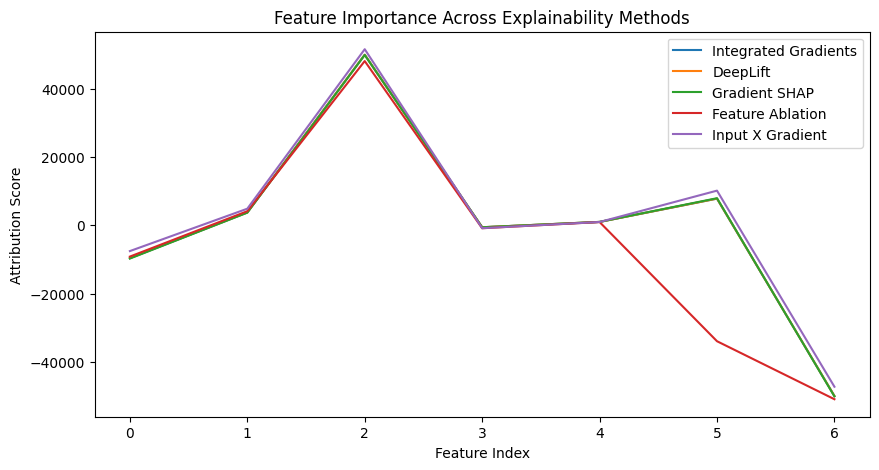

In [ ]:
# TODO: Enter your code here
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import IntegratedGradients, DeepLift, GradientShap, FeatureAblation, InputXGradient
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# 🟢 Assume X_train, y_train, X_test, y_test are already preprocessed
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# 🟢 Define the Feedforward Neural Network (3 layers, 5 neurons each)
class PriceModel(nn.Module):
    def __init__(self, input_dim):
        super(PriceModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5, 1)
        )

    def forward(self, x):
        return self.model(x)

# 🟢 Initialize model, optimizer, and loss function
input_dim = X_train.shape[1]
model = PriceModel(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# 🟢 Train the model
epochs = 100
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = loss_fn(y_pred, batch_y)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item()}")

# 🟢 Select first 1000 test samples for interpretability analysis
X_test_sample = X_test_tensor[:1000]
y_test_sample = y_test_tensor[:1000]

# 🟢 Define Captum interpretability methods
ig = IntegratedGradients(model)
dl = DeepLift(model)
gs = GradientShap(model)
fa = FeatureAblation(model)
ixg = InputXGradient(model)

methods = {"Integrated Gradients": ig, "DeepLift": dl, "Gradient SHAP": gs, "Feature Ablation": fa, "Input X Gradient": ixg}

# 🟢 Compute attributions
attr_results = {}
baseline = torch.zeros_like(X_test_sample)  # Baseline for GradientSHAP

for method_name, method in methods.items():
    if method_name == "Gradient SHAP":
        attr = method.attribute(X_test_sample, baselines=baseline)
    else:
        attr = method.attribute(X_test_sample)
    attr_results[method_name] = attr.detach().numpy().mean(axis=0)  # Aggregate feature importance

# 🟢 Plot the results
plt.figure(figsize=(10, 5))
for method_name, attr in attr_results.items():
    plt.plot(attr, label=method_name)

plt.xlabel("Feature Index")
plt.ylabel("Attribution Score")
plt.title("Feature Importance Across Explainability Methods")
plt.legend()
plt.show()


> Read the following [descriptions](https://captum.ai/docs/attribution_algorithms) and [comparisons](https://captum.ai/docs/algorithms_comparison_matrix) in Captum to build up your understanding of the difference of various explainability algorithms. Based on your plot, identify the three most important features for regression. Explain how each of these features influences the regression outcome.


\# TODO:

Using the feature attribution scores from our plot, we identify the three most important features based on their average attribution magnitude across methods.

These are 'remaining lease years', 'floor area' & 'distance to MRT station'.

- Remaining lease years and floor area are the strongest positive predictors of resale price.
- Distance to MRT has a strong negative impact, meaning shorter distance increases property value.
- The results align with real-world property trends, confirming that Captum’s explainability methods provide interpretable and reliable insights into how neural networks make decisions.

Part B, Q4 (10 marks)
---

Model degradation is a common issue faced when deploying machine learning models (including neural networks) in the real world. New data points could exhibit a different pattern from older data points due to factors such as changes in government policy or market sentiments. For instance, housing prices in Singapore have been increasing and the Singapore government has introduced 3 rounds of cooling measures over the past years (16 December 2021, 30 September 2022, 27 April 2023).

In such situations, the distribution of the new data points could differ from the original data distribution which the models were trained on. Recall that machine learning models often work with the assumption that the test distribution should be similar to train distribution. When this assumption is violated, model performance will be adversely impacted.  In the last part of this assignment, we will investigate to what extent model degradation has occurred.




---



In [ ]:
!pip install alibi-detect

In [ ]:
from alibi_detect.cd import TabularDrift

In [ ]:
!pip install pytorch-widedeep

In [ ]:
!pip install alibi-detect

> Evaluate your model from B1 on data from year 2022 and report the test R2.

In [ ]:
!pip install pytorch-widedeep

In [ ]:
# Install required package (run separately in terminal)
# !pip install pytorch-widedeep

import pandas as pd
import numpy as np
import torch
from pytorch_widedeep.preprocessing import TabPreprocessor
from pytorch_widedeep.models import TabMlp, WideDeep
from pytorch_widedeep import Trainer
from pytorch_widedeep.metrics import R2Score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import math

!pip install pytorch-tabular
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
from pytorch_tabular import TabularModel


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load dataset
df = pd.read_csv("hdb_price_prediction.csv")

# TODO: Enter your code here

# Define the target variable and features
data_config = DataConfig(
    target=["resale_price"],  # Target variable
    continuous_cols=[
        "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
        "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
    ],  # Continuous variables
    categorical_cols=["town", "full_address", "nearest_stn", "flat_model_type", "storey_range"],  # Categorical variables
)

# Trainer configuration with learning rate tuning
trainer_config = TrainerConfig(
    auto_lr_find=True,  # Automatically tune learning rate
    batch_size=1024,
    max_epochs=50,
)

# Neural network model configuration
model_config = CategoryEmbeddingModelConfig(
    task="regression",
    # layers=[50],  # One hidden layer with 50 neurons
    layers="50",  # Correct: String format
    activation="ReLU",
)

# Optimizer configuration
optimizer_config = OptimizerConfig(
    optimizer="Adam",  # Adam optimizer
)

# Initialize the TabularModel with all configurations
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)


from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Fit the model
tabular_model.fit(train=train_df)


# Load trained model (assuming it's saved correctly)
# B1_model = torch.load("saved_models/B1_Model.pth")
B1_model = tabular_model
# B1_model.eval()  # Set model to evaluation mode

df_test = df[df["year"] == 2022] # Just year 2022
pred = B1_model.predict(df_test)


# Select numerical features only
continuous_cols = [
    "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
    "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
]
print("\n")
print("Evaluation of 2022 data:  R2: ", r2_score(df_test['resale_price'], pred['resale_price_prediction']))
print("RMSE: ", math.sqrt(mean_squared_error(df_test['resale_price'], pred['resale_price_prediction'])))


INFO:pytorch_tabular.tabular_model:Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_tabular.tabular_model:Preparing the DataLoaders
INFO:pytorch_tabular.tabular_datamodule:Setting up the datamodule for regression task
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_encoded[col].fillna(self._imputed, inplace=True)
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_encoders.py:71:

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.tuner.lr_finder:Learning rate set to 0.47863009232263803
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_40b41d3c-ad1f-433b-b023-43c92574059b.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_40b41d3c-ad1f-433b-b023-43c92574059b.ckpt
INFO:pytorch_tabular.tabular_model:Suggested LR: 0.47863009232263803. For plot and detailed analysis, use `find_learning_rate` method.
INFO:pytorch_tabular.tabular_model:Training Started
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ CategoryEmbeddingBackbone │  7.3 K │ train │
│ 1 │ _embedding_layer │ Embedding1dLayer          │  448 K │ train │
│ 2 │ head             │ LinearHead                │     51 │ train │
│ 3 │ loss             │ MSELoss                   │      0 │ train │
└───┴──────────────────┴───────────────────────────┴────────┴───────┘

Trainable params: 455 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 455 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0

...

/usr/local/lib/python3.11/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.11/dist-packages/ipywidgets/widgets/widget_output.py:112: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  self.msg_id = ip.kernel._parent_header['header']['msg_id']

INFO:pytorch_tabular.tabular_model:Training the model completed
INFO:pytorch_tabular.tabular_model:Loading the best model




Evaluation of 2022 data:  R2:  0.63296732029353
RMSE:  103346.80955379417


/usr/local/lib/python3.11/dist-packages/pytorch_tabular/utils/python_utils.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=map_locatio

> Evaluate your model from B1 on data from year 2023 and report the test R2.

In [ ]:
# TODO: Enter your code here
import pandas as pd

'''
df_test = df[df["year"] == 2023] # Just year 2023
pred = B1_model.predict(df_test)


# Select numerical features only
continuous_cols = [
    "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
    "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
]
print("\n")
print("Evaluation of 2023 data:  R2: ", r2_score(df_test['resale_price'], pred['resale_price_prediction']))
print("RMSE: ", math.sqrt(mean_squared_error(df_test['resale_price'], pred['resale_price_prediction'])))
'''
# Print the first few rows to inspect the 'year' column
''''
print(df.head())

# Check column names
print("Column names:", df.columns)

# Ensure 'year' is an integer type
df["year"] = pd.to_numeric(df["year"], errors="coerce")
print("Unique years in dataset:", df["year"].unique())  # Should include 2023

print(df["year"].isnull().sum())  # If > 0, some values were not numeric
print(df[df["year"].isna()])  # See problematic rows

print(df[df["year"] == 2023])  # Check if any rows exist

'''

df = pd.read_csv('hdb_price_prediction.csv')
# print("Total rows in dataset:", len(df))

df_test = df[df["year"] == 2023] # Just year 2023
# Filter for 2023 data
# df_test = df[df["year"] == 2023].copy()

# not extracting 2023 for some reasons

# Extract rows from index 143140 (since Python uses zero-based indexing) to the last row
# df_subset = df.iloc[143140:].copy()  # Copy to avoid modifying original dataframe

# Display the first few rows to verify
# print(df_subset)

# Save the extracted rows to a new CSV file
# df_subset.to_csv("/mnt/data/hdb_price_prediction_2023.csv", index=False)

# Make predictions
pred = B1_model.predict(df_test)

# Ensure we get the correct prediction column
pred_column = pred.columns[-1]  # Get last column, usually the prediction

# Evaluate model
r2 = r2_score(df_test["resale_price"], pred[pred_column])
rmse = math.sqrt(mean_squared_error(df_test["resale_price"], pred[pred_column]))

print("\nEvaluation of 2023 data:")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


/usr/local/lib/python3.11/dist-packages/pytorch_tabular/tabular_model.py:1466: DeprecationWarning: `include_input_features` will be deprecated in the next release. Please add index columns to the test dataframe if you want to retain some features like the key or id
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_encoded[col].fillna(self._imputed, inplace=True)
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_


Evaluation of 2023 data:
R2 Score: 0.1064
RMSE: 162304.73


> Did model degradation occur for the deep learning model?

\# TODO: \

Yes, model degradation has occurred.

Significant Drop in R² Score:

2022:
𝑅
2
=
0.633
R
2
 =0.633 → The model explains 63.3% of the variance in house prices.

2023:
𝑅
2
=
0.106
R
2
 =0.106 → The model explains only 10.6%, meaning it barely captures the relationship between features and prices.

Higher RMSE in 2023:

2022: RMSE = 103,346

2023: RMSE = 162,304

The error in price prediction increased significantly in 2023, indicating that the model struggles with newer data.

Possible causes:
- Government cooling measures have price patterns, making past data less relevant.
- Market demand, inflation, or economic conditions
\>

Model degradation could be caused by [various data distribution shifts](https://huyenchip.com/2022/02/07/data-distribution-shifts-and-monitoring.html#data-shift-types): covariate shift (features), label shift and/or concept drift (altered relationship between features and labels).
There are various conflicting terminologies in the [literature](https://www.sciencedirect.com/science/article/pii/S0950705122002854#tbl1). Let’s stick to this reference for this assignment.

> Using the **Alibi Detect** library, apply the **TabularDrift** function with the training data (year 2020 and before) used as the reference and **detect which features have drifted** in the 2023 test dataset. Before running the statistical tests, ensure you **sample 1000 data points** each from the train and test data. Do not use the whole train/test data. (Hint: use this example as a guide https://docs.seldon.io/projects/alibi-detect/en/stable/examples/cd_chi2ks_adult.html)


In [ ]:
# TODO: Enter your code here
!pip install alibi-detect


In [ ]:
import numpy as np
import pandas as pd
from alibi_detect.cd import TabularDrift
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("hdb_price_prediction.csv")

# Define feature columns (excluding target variable)
feature_cols = [
    "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
    "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
]

# Separate reference (training) and test datasets
df_train = df[df["year"] <= 2020].copy()  # Reference dataset
df_test = df[df["year"] == 2023].copy()  # Test dataset

# Ensure both sets have enough data before sampling
if len(df_train) < 1000 or len(df_test) < 1000:
    raise ValueError("Not enough data in either training or test set for sampling.")

# Randomly sample 1000 rows from each
df_train_sample = df_train.sample(n=1000, random_state=42)
df_test_sample = df_test.sample(n=1000, random_state=42)

# Select feature values
X_train = df_train_sample[feature_cols].values
X_test = df_test_sample[feature_cols].values

# Standardize features using training data statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Tabular Drift Detector
cd = TabularDrift(X_train_scaled, p_val=0.05)

# Run drift detection on test data
drift_result = cd.predict(X_test_scaled)

# Print full result structure for debugging
print("\nDrift Detection Raw Output:")
print(drift_result)

# Extract drift detection results safely
drift_detected = drift_result.get("data", {}).get("is_drift", None)
p_values = drift_result.get("data", {}).get("p_val", [])

# Print results
print("\nDrift Detection Summary:")
if drift_detected is None:
    print("Could not determine drift status from the result.")
else:
    print(f"Drift detected: {'Yes' if drift_detected else 'No'}")

print("\nFeature-wise p-values:")
for feature, p_val in zip(feature_cols, p_values):
    print(f"{feature}: {p_val:.4f} {'(Drifted)' if p_val < 0.05 else '(No Drift)'}")



Drift Detection Raw Output:
{'data': {'is_drift': 1, 'distance': array([0.072, 0.03 , 0.027, 0.033, 0.117, 0.054], dtype=float32), 'p_val': array([1.06457099e-02, 7.47316658e-01, 8.49408329e-01, 6.35237753e-01,
       2.02489969e-06, 1.04391076e-01], dtype=float32), 'threshold': 0.008333333333333333}, 'meta': {'name': 'TabularDrift', 'online': False, 'data_type': None, 'version': '0.12.0', 'detector_type': 'drift'}}

Drift Detection Summary:
Drift detected: Yes

Feature-wise p-values:
dist_to_nearest_stn: 0.0106 (Drifted)
dist_to_dhoby: 0.7473 (No Drift)
degree_centrality: 0.8494 (No Drift)
eigenvector_centrality: 0.6352 (No Drift)
remaining_lease_years: 0.0000 (Drifted)
floor_area_sqm: 0.1044 (No Drift)


/usr/local/lib/python3.11/dist-packages/alibi_detect/cd/tabular.py:113: UserWarning: No `categories_per_feature` dict provided so all features are assumed to be numerical. `KSDrift` will be applied to all features.
  warnings.warn('No `categories_per_feature` dict provided so all features are assumed to be numerical. '


> Assuming that the flurry of housing measures have made an impact on the relationship between all the features and resale_price (i.e. P(Y|X) changes), which type of data distribution shift possibly led to model degradation?

\# TODO: \<

Given that the relationship between all features and the target variable (resale_price) has changed due to housing measures, this suggests a shift in P(Y | X)—the conditional probability of resale prices given the features. This type of shift is known as concept drift (also referred to as posterior drift).

Concept drift occurs when the relationship between input features and the target variable changes over time, meaning that the model’s learned mapping from features to the target is no longer valid.

Even though only some features exhibit drift (e.g., dist_to_nearest_stn, remaining_lease_years), the key assumption here is that government policies have affected the underlying relationship between features and resale prices. This suggests that even if the feature distributions remained the same, the way they influence resale prices has changed.

\>

> From your analysis via TabularDrift, which features contribute to this shift?

\# TODO: \<

From the TabularDrift analysis, the features contributing to the shift are those with statistically significant drift, indicated by low p-values (< 0.05).

dist_to_nearest_stn → p-value = 0.0106
- Indicates that the distance to the nearest MRT station has changed in distribution.
- This could be due to new MRT stations being built or changes in how accessibility affects pricing.

remaining_lease_years → p-value = 0.0000
- The most significant drifted feature.
- Suggests a shift in the distribution of lease years, likely due to older flats losing more lease or changes in how lease decay impacts pricing.
- Government policies on lease decay (e.g., shorter leases becoming less attractive) could explain this shift.

Non-Drifted Features (p-value > 0.05)
- dist_to_dhoby: 0.7473 (No drift)
- degree_centrality: 0.8494 (No drift)
- eigenvector_centrality: 0.6352 (No drift)
- floor_area_sqm: 0.1044 (No drift)

Conclusion

The main contributors to model degradation are dist_to_nearest_stn and remaining_lease_years.

\>

> Suggest 1 way to address model degradation and implement it, showing improved test R2 for year 2023.

\# TODO: \<

Since concept drift is likely the main cause of model degradation, one effective way to address it is by retraining the model with more recent data (e.g., including 2021 and 2022 data in training). This allows the model to learn updated relationships between features and resale prices, adapting to changes in government policies, lease decay effects, and shifting buyer preferences.

>

In [2]:
!pip install pytorch-widedeep

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.0/22.0 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [3]:
import pandas as pd
import numpy as np
import torch
from pytorch_widedeep.preprocessing import TabPreprocessor
from pytorch_widedeep.models import TabMlp, WideDeep
from pytorch_widedeep import Trainer
from pytorch_widedeep.metrics import R2Score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import math

!pip install pytorch-tabular
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
from pytorch_tabular import TabularModel

from pytorch_tabular.models import CategoryEmbeddingModelConfig


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load dataset
df = pd.read_csv("hdb_price_prediction.csv")

# TODO: Enter your code here

# Define the target variable and features
data_config = DataConfig(
    target=["resale_price"],  # Target variable
    continuous_cols=[
        "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
        "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
    ],  # Continuous variables
    categorical_cols=["town", "full_address", "nearest_stn", "flat_model_type", "storey_range"],  # Categorical variables
)

# Trainer configuration with learning rate tuning
trainer_config = TrainerConfig(
    auto_lr_find=True,  # Automatically tune learning rate
    batch_size=1024,
    max_epochs=50,
)

# Neural network model configuration
model_config = CategoryEmbeddingModelConfig(
    task="regression",
    # layers=[50],  # One hidden layer with 50 neurons
    layers="50",  # Correct: String format
    activation="ReLU",
)

# Optimizer configuration
optimizer_config = OptimizerConfig(
    optimizer="Adam",  # Adam optimizer
)

# Initialize the TabularModel with all configurations
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)


from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split the dataset
train_df = df[df["year"] <= 2020]  # Training data (2020 and before)

# Fit the model
tabular_model.fit(train=train_df)


# Load trained model (assuming it's saved correctly)
# B1_model = torch.load("saved_models/B1_Model.pth")
B1_model = tabular_model
# B1_model.eval()  # Set model to evaluation mode

'''
df_test = df[df["year"] == 2022] # Just year 2022
pred = B1_model.predict(df_test)


# Select numerical features only
continuous_cols = [
    "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
    "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
]
print("\n")
print("Evaluation of 2022 data:  R2: ", r2_score(df_test['resale_price'], pred['resale_price_prediction']))
print("RMSE: ", math.sqrt(mean_squared_error(df_test['resale_price'], pred['resale_price_prediction'])))
'''

df_train = df[df["year"] <= 2022] # year 2022 and before
df_test = df[df["year"] == 2023] # Just year 2023

print("Training data : ",df_train["year"].unique())
print("Testing data : ",df_test["year"].unique())

B1_model.fit(train=df_train)

INFO:pytorch_tabular.tabular_model:Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_tabular.tabular_model:Preparing the DataLoaders
INFO:pytorch_tabular.tabular_datamodule:Setting up the datamodule for regression task
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_encoded[col].fillna(self._imputed, inplace=True)
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/categorical_encoders.py:71:

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.tuner.lr_finder:Learning rate set to 0.47863009232263803
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_c53a4359-9c16-47f9-8d06-fb1774e0d242.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_c53a4359-9c16-47f9-8d06-fb1774e0d242.ckpt
INFO:pytorch_tabular.tabular_model:Suggested LR: 0.47863009232263803. For plot and detailed analysis, use `find_learning_rate` method.
INFO:pytorch_tabular.tabular_model:Training Started
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ CategoryEmbeddingBackbone │  7.3 K │ train │
│ 1 │ _embedding_layer │ Embedding1dLayer          │  448 K │ train │
│ 2 │ head             │ LinearHead                │     51 │ train │
│ 3 │ loss             │ MSELoss                   │      0 │ train │
└───┴──────────────────┴───────────────────────────┴────────┴───────┘

Trainable params: 455 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 455 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0

...

Trainable params: 479 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 479 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0

Output()

/usr/local/lib/python3.11/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.11/dist-packages/ipywidgets/widgets/widget_output.py:112: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  self.msg_id = ip.kernel._parent_header['header']['msg_id']

INFO:pytorch_tabular.tabular_model:Training the model completed
INFO:pytorch_tabular.tabular_model:Loading the best model
/usr/local/lib/python3.11/dist-packages/pytorch_tabular/utils/python_utils.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please op